# Imports

In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# Define State 

In [11]:
class TemperatureState(TypedDict):
    temp_celsius: float
    temp_fahrenheit: float
    weather_status: str

# Convert Temperature Function (First Node)

In [12]:
def convert_temp(state: TemperatureState) -> TemperatureState:
    celsius = state['temp_celsius']
    # Convert Celsius to Fahrenheit
    fahrenheit = (celsius * 9/5) + 32
    state['temp_fahrenheit'] = round(fahrenheit, 2)

    return state


# Lebel weather condition (Second Node)

In [13]:
def label_weather(state: TemperatureState) -> TemperatureState:
    
    # Pull Fahrenheit from the state instead of Celsius
    fahrenheit = state['temp_fahrenheit']
    
    if fahrenheit < 50:
        state["weather_status"] = "Cold"
    elif 50 <= fahrenheit < 77:
        state["weather_status"] = "Mild"
    elif 77 <= fahrenheit < 95:
        state["weather_status"] = "Hot"
    else:
        state["weather_status"] = "Extreme Heat"
        
    return state

# Define and Compile Graph

In [14]:
# define your graph
graph = StateGraph(TemperatureState)

#add nodes to the graph
graph.add_node('convert_temp',convert_temp)
graph.add_node('label_weather', label_weather)


# add edges to the graph
graph.add_edge(START, 'convert_temp')
graph.add_edge('convert_temp', 'label_weather')
graph.add_edge('label_weather', END)


# Compile the graph
workflow = graph.compile()


# Execute Graph 

In [15]:
# execute the graph
initial_state = {'temp_celsius': 28.5}
final_state = workflow.invoke(initial_state)
print(final_state)


{'temp_celsius': 28.5, 'temp_fahrenheit': 83.3, 'weather_status': 'Hot'}


# Visualize Graph

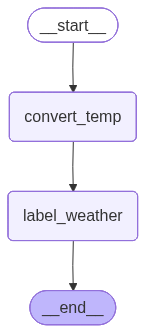

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())